---

# **📘 ResNet 논문 분석 — Deep Residual Learning for Image Recognition**

---

### **1. Abstract (3줄 요약)**
문제: 딥러닝 네트워크를 <ins>깊게 쌓을수록 학습이 오히려 잘 안 되는 "degradation(성능 저하)" 문제가 발생</ins>한다.  

방법: 레이어가 결과값 전체를 학습하는 대신, <ins>입력과의 "차이(잔차, residual)"만 학습하도록</ins> 수식을 F(x)+x 형태로 바꾼다.  

결과: 152층짜리 네트워크로 ImageNet에서 top-5 error 3.57%를 달성, ILSVRC 2015 1위를 차지했다.

---
### **2. Introduction + Conclusion 요약**  
</br>

**왜 이 논문이 나왔나?**  
</br>

딥러닝에서 "층(layer)이 깊을수록 좋다"는 건 상식이었습니다. <ins>층이 많을수록 더 복잡한 패턴을 배울 수 있거든요.</ins> 그런데 문제가 생겼습니다.  
</br>
</br>
**기존 방식의 문제점**
</br>
</br>

**기울기 소실(vanishing gradient) 문제**라는 게 있었습니다. 쉽게 말하면, <ins>학습 신호가 뒤쪽 층에서 앞쪽 층으로 전달되는데, 층이 너무 많으면 신호가 전달되는 도중 점점 약해져서 앞쪽 층은 아무것도 배우지 못하는 현상</ins>입니다. 마치 귀에서 귀로 전달되는 "전화기 게임"처럼, 메시지가 흐릿해지는 것이죠.</br>
이 문제는 <ins>배치 정규화(Batch Normalization) 같은 기법으로 어느 정도 해결</ins>됐습니다. 그런데 그 이후에 또 다른 문제가 발견되었습니다.
바로 **성능 저하(degradation) 문제**입니다. <ins>층을 더 쌓으면 오히려 훈련 오류(training error)가 높아지는 현상</ins>인데, 이건 <ins>과적합(overfitting) 때문이 아닙니다. 진짜로 학습 자체가 잘 안 되는 것</ins>이었습니다.
논문의 Figure 1을 보면, 56층 네트워크가 20층 네트워크보다 오히려 성능이 나쁩니다. 직관적으로 이해가 안 가죠? 이론적으로 더 깊은 네트워크는 얕은 네트워크가 하는 일을 그대로 따라할 수 있어야 하는데, 실제로는 그렇게 되지 않았습니다.  
</br>
**이 논문의 해결책**     
</br>
핵심 아이디어: 층이 "정답"을 직접 학습하는 게 아니라, **"원래 입력과 정답의 차이(잔차, residual)"만 학습하게 만들자!**
수식으로 보면: 기존 방식은 H(x)를 직접 학습. ResNet 방식은 F(x) = H(x) - x 를 학습하고, 최종 출력을 F(x) + x로 만듦.
그리고 이 x를 출력에 더해주는 연결을 숏컷 연결(shortcut connection) 또는 **스킵 연결(skip connection)** 이라고 부릅니다.  

  

---

### **3. 핵심 구조 설명**
① **합성곱 층** (Convolutional Layer)  

비유 먼저: 사진에서 <ins>특정 패턴(가장자리, 질감, 색상)을 찾아내는</ins> "**돋보기**"입니다. <ins>돋보기를 이미지 위에서 쭉 훑으면서 패턴이 있는지 없는지 체크</ins>합니다.



*   입력값: **(batch, 채널 수, 높이, 너비)** 형태의 <ins>4차원 텐서</ins>. </br>예) (32, 3, 224, 224) = 32장 이미지, RGB 3채널, 224×224 픽셀</br>

*   출력값: **(batch, 필터 수, 새 높이, 새 너비)** 형태. </br>필터 수와 이미지 크기가 바뀜.
*   하이퍼파라미터: **필터 크기**(예: 3×3, 7×7), **필터 개수**(채널 수), **스트라이드**(stride, 돋보기를 몇 칸씩 이동할지), **패딩**(padding)



② **배치 정규화** (Batch Normalization)  

비유 먼저: 시험 점수가 과목마다 들쭉날쭉할 때, <ins>"평균 0, 표준편차 1"로 맞춰주는 표준화</ins>처럼, **각 층의 출력값 분포를 일정하게 맞춰주는 작업**입니다.  


*   입력값: <ins>합성곱 층의 출력 텐서</ins></br>

*   출력값: <ins>평균 0, 표준편차 1에 가깝게</ins>  **정규화된 텐서**     (같은 shape)</br>

*   하이퍼파라미터: 없음 (γ, β는 학습되는 파라미터)



③ **ReLU 활성화 함수** (Activation Function)  

비유 먼저: <ins>"0 이하는 무시하고, 0 이상은 그대로 통과"시키는 필터</ins>입니다. **음수는 다 0**으로 만들어버립니다.



*   입력값: 어떤 shape의 텐서든 가능

*   출력값: 같은 shape, 음수 값만 0으로 바뀜

*   하이퍼파라미터: 없음


④ **잔차 블록 **(Residual Block) 🔴 (핵심)  

비유 먼저: 학생이 시험 답안을 처음부터 쓰는 게 아니라, **"기존 답안에서 틀린 부분만 수정"하는 방식**입니다. 완전히 새 답안을 쓰는 것보다 훨씬 쉽겠죠?  </br></br>



기존 방식:</br> **y = F(x)** </br>→ 처음부터 정답을 학습</br></br>



ResNet 방식:</br> **y = F(x) + x**</br>→ x (원래 입력)에 수정분만 더함  

이때 <ins>x를 그대로 더해주는 연결</ins>이 **숏컷 연결**(shortcut connection)입니다.  
  
</br></br>
두 가지 버전:  


기본 블록 (Basic Block, ResNet-18/34용):


*   <ins>Conv → BN → ReLU → Conv → BN → (+x) → ReLU</ins>
*   **3×3 합성곱 2개 사용**  
</br>
</br>

**병목 블록** (Bottleneck Block, ResNet-50/101/152용): 🔴 (핵심)  

*   **1×1 Conv → BN → ReLU → 3×3 Conv → BN → ReLU → 1×1 Conv → BN → (+x) → ReLU**

*   <ins>1×1 합성곱으로 채널을 먼저 줄이고(병목)</ins>, <ins>3×3 합성곱 처리 후,</ins> <ins>다시 1×1로 채널을 늘림</ins>

*   <ins>**계산량을 줄이면서도 깊은 네트워크를 만들 수 있음**</ins>
  
입력값: (batch, C, H, W)  

출력값: (batch, C, H, W) — shape 동일 (채널이 변하는 경우 숏컷도 1×1 Conv로 채널 조정)  

하이퍼파라미터: 블록 반복 횟수(n), 필터 수


⑤ **전역 평균 풀링** (Global Average Pooling)  

비유 먼저: 반 전체 학생 점수를 일일이 다 보는 대신, <ins>평균 하나로 요약하는 것처럼</ins>, H×W 크기의 <ins>특징 맵을 픽셀 하나로 압축</ins>합니다.  


*   입력값: (batch, C, H, W)
*   출력값: **(batch, C, 1, 1) → 보통 (batch, C)로 flatten**
*   하이퍼파라미터: 없음



⑥ **완전연결층 + Softmax** (Fully Connected + Softmax)  

비유 먼저: <ins>여러 단서(특징)를 취합해서 "이건 고양이일 확률 80%, 강아지일 확률 15%, 새일 확률 5%"처럼 최종 **분류**</ins>를 내리는 **"판사" 역할**입니다.  


*   입력값: (batch, 2048) 형태의 벡터  

*   출력값: (batch, 1000) — <ins>1000개 클래스 각각의 확률값</ins>  

*   하이퍼파라미터: 출력 클래스 수 (ImageNet은 1000)  



---  
### **4. 구조 시각화**  
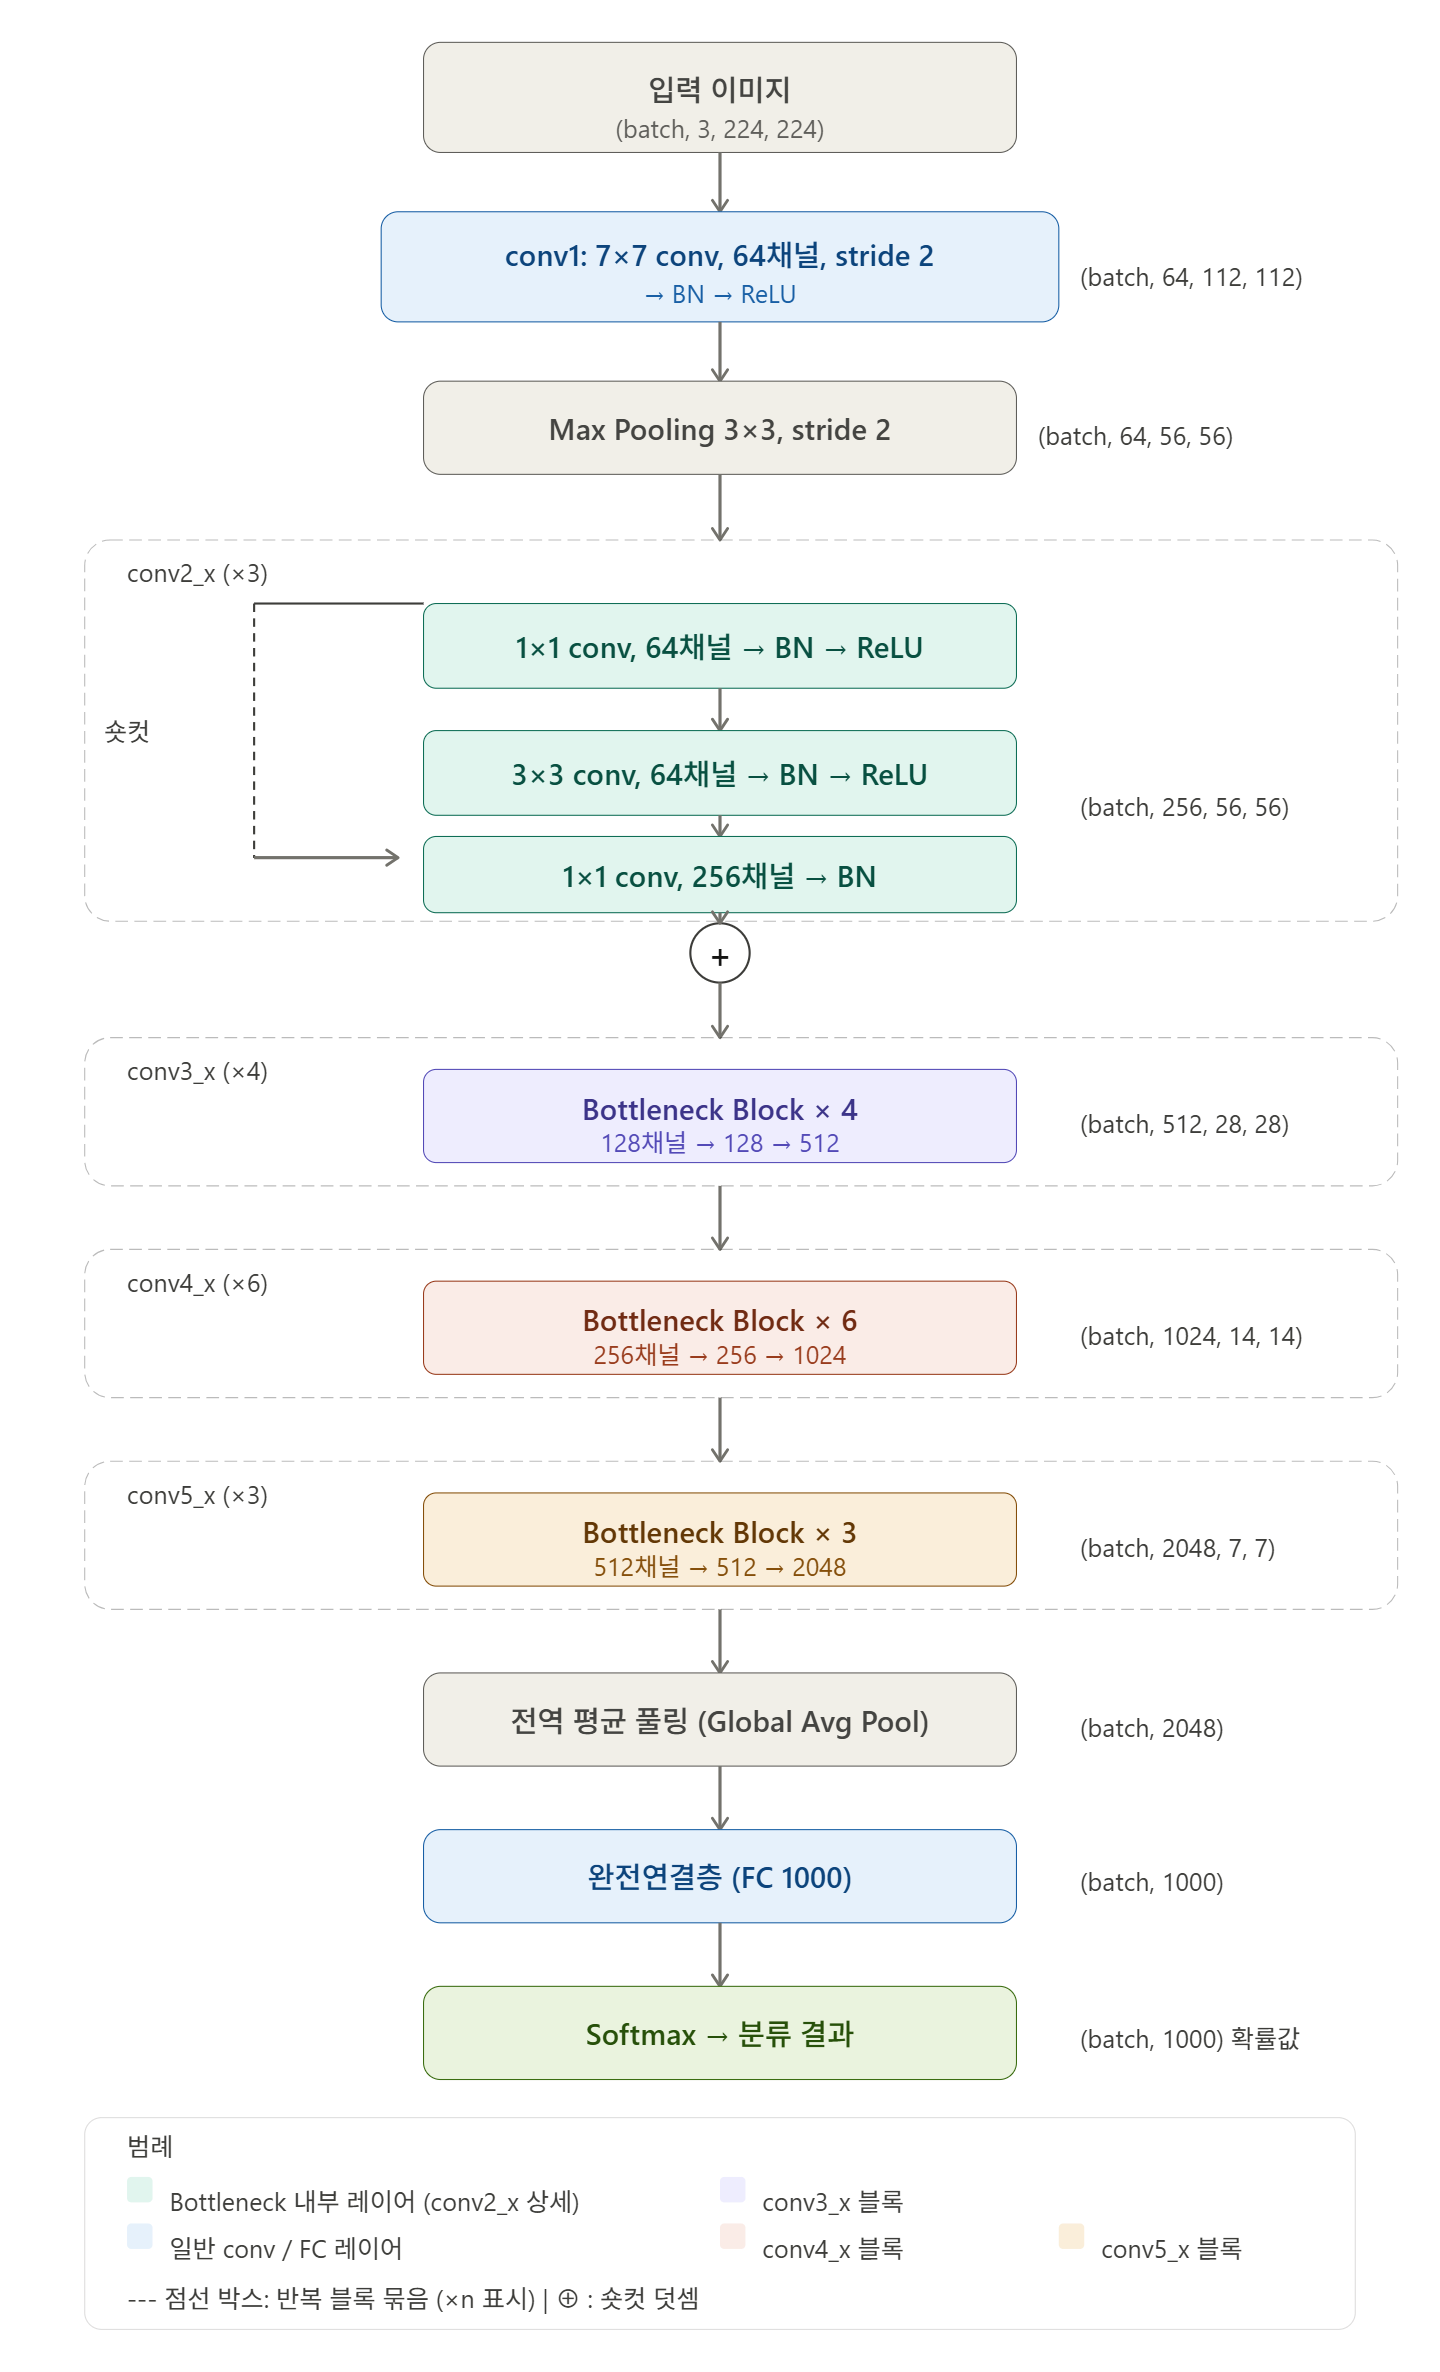

---

### **5. 논문 ↔ 코드 연결 (PyTorch)**  
논문 → 코드 매핑:</br>  



*   논문: "7×7 conv, 64 filters, stride 2" → 코드: nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)  

*   논문: "BN right after each convolution" → 코드: nn.BatchNorm2d(64)  

*   논문: "ReLU activation" → 코드: nn.ReLU(inplace=True)  

*   논문: "3×3 max pool, stride 2" → 코드: nn.MaxPool2d(kernel_size=3, stride=2, padding=1)  

*   논문: "F(x) + x (shortcut connection)" → 코드: out += self.shortcut(x) (잔차 덧셈)  

*   논문: "1×1 conv to match dimensions" → 코드: nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)  

*   논문: "global average pooling" → 코드: nn.AdaptiveAvgPool2d((1, 1))  

*   논문: "1000-way FC with softmax" → 코드: nn.Linear(2048, 1000)

**전체 ResNet-50 구현 코드:**  

In [ ]:
import torch
import torch.nn as nn

# ① 병목 블록 (Bottleneck Block) - ResNet-50/101/152용
class BottleneckBlock(nn.Module):
    expansion = 4  # 출력 채널 = 입력 채널 × 4

    def __init__(self, in_channels, mid_channels, stride=1):
        super().__init__()

        # 논문의 F(x) 부분 (잔차 학습)
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(mid_channels)

        self.conv2 = nn.Conv2d(mid_channels, mid_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(mid_channels)

        self.conv3 = nn.Conv2d(mid_channels, mid_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(mid_channels * self.expansion)

        self.relu  = nn.ReLU(inplace=True)

        # 숏컷 연결 - 채널 수나 크기가 다를 때 1×1 conv로 맞춤
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != mid_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, mid_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(mid_channels * self.expansion)
            )

    def forward(self, x):
        identity = x  # 원래 입력값 저장 (숏컷용)

        out = self.relu(self.bn1(self.conv1(x)))   # 1×1 conv
        out = self.relu(self.bn2(self.conv2(out))) # 3×3 conv
        out = self.bn3(self.conv3(out))            # 1×1 conv (ReLU 전)

        # 핵심! F(x) + x
        out += self.shortcut(identity)
        out = self.relu(out)
        return out


# ② 전체 ResNet-50 모델
class ResNet50(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()

        # conv1
        self.conv1   = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # conv2_x ~ conv5_x
        self.layer1 = self._make_layer(64,   64,  blocks=3, stride=1)
        self.layer2 = self._make_layer(256,  128, blocks=4, stride=2)
        self.layer3 = self._make_layer(512,  256, blocks=6, stride=2)
        self.layer4 = self._make_layer(1024, 512, blocks=3, stride=2)

        # 분류기
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(2048, num_classes)

    def _make_layer(self, in_channels, mid_channels, blocks, stride):
        layers = [BottleneckBlock(in_channels, mid_channels, stride=stride)]
        for _ in range(1, blocks):
            layers.append(BottleneckBlock(mid_channels * 4, mid_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))  # conv1
        x = self.layer1(x)  # conv2_x
        x = self.layer2(x)  # conv3_x
        x = self.layer3(x)  # conv4_x
        x = self.layer4(x)  # conv5_x
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# 사용 예시
model = ResNet50(num_classes=1000)
dummy = torch.randn(1, 3, 224, 224)  # 이미지 1장
output = model(dummy)
print(output.shape)  # → torch.Size([1, 1000])

---

### **6. 데이터 흐름 추적 (Shape 변화)**  
ResNet-50 기준으로 이미지 1장(batch=1)이 통과할 때의 shape 변화입니다.  

형식: `(batch, C, H, W)` → [Layer] → `(변경된 shape)`

| 단계 | 입력 Shape | 출력 Shape | 이유 |
|------|-----------|-----------|------|
| 입력 이미지 | — | `(1, 3, 224, 224)` | RGB 3채널, 224×224px |
| Conv1 (7×7, stride 2, 64 filters) | `(1, 3, 224, 224)` | `(1, 64, 112, 112)` | 224 ÷ 2 = 112, 채널 3 → 64 |
| MaxPool (3×3, stride 2) | `(1, 64, 112, 112)` | `(1, 64, 56, 56)` | 112 ÷ 2 = 56, 채널 유지 |
| conv2_x (Bottleneck × 3) | `(1, 64, 56, 56)` | `(1, 256, 56, 56)` | 공간 크기 유지, 채널 64 × 4 = 256으로 확장 |
| conv3_x (Bottleneck × 4, stride 2) | `(1, 256, 56, 56)` | `(1, 512, 28, 28)` | 56 ÷ 2 = 28, 채널 128 × 4 = 512 |
| conv4_x (Bottleneck × 6, stride 2) | `(1, 512, 28, 28)` | `(1, 1024, 14, 14)` | 28 ÷ 2 = 14, 채널 256 × 4 = 1024 |
| conv5_x (Bottleneck × 3, stride 2) | `(1, 1024, 14, 14)` | `(1, 2048, 7, 7)` | 14 ÷ 2 = 7, 채널 512 × 4 = 2048 |
| Global Average Pooling → Flatten | `(1, 2048, 7, 7)` | `(1, 2048)` | 7×7 특징 맵을 평균 내어 1개 숫자로 압축 후 1D 펼침 |
| FC Layer (2048 → 1000) | `(1, 2048)` | `(1, 1000)` | 1000개 클래스 점수로 선형 변환 |
| Softmax (최종 출력) | `(1, 1000)` | `(1, 1000)` | 합계 = 1.0인 확률값으로 변환 |

---

**핵심 패턴 정리:**  


*   **이미지 크기(H, W)가 절반**이 될 때마다 **채널 수는 두 배**가 됩니다. (계산량을 일정하게 유지하는 설계 원칙)
*   병목 블록에서 채널은 항상 "**압축 → 처리 → 복원**" 패턴을 따릅니다. (예: 256 → 64 → 64 → 256)

